# _4.1.4. (binary) classification using TabNet_

This is the main topics of the current notebook. We will focus on applying TabNet to the problem of anomaly detection, i.e., in the current case separating normal/abnormal samples.

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: ok


In [2]:
import pandas as pd
import numpy as np
import os
import time
import torch

from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import train_test_split

from pytorch_tabnet.tab_model import TabNetClassifier

%matplotlib inline

In [3]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(2)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0


In [4]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "tag2"

In [5]:
dataset_name = 'new_godash_dataset'
train = new_df
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

###### (normal vs abnormal)

The basic Idea here is to see the problem as a binary classification problem. 

The population is already devided into _normal_ and _abnormal_

In [6]:
train[target].value_counts(normalize=True)

True     0.746951
False    0.253049
Name: tag2, dtype: float64

#### _c. Split_

In [7]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices = train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'anomaly', 'level', 'tag']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("X_train (shape) = ", X_train.shape, "--> ", round((X_train.shape[0]/train.shape[0])*100,2), "%")
print ("X_valid (shape) = ", X_valid.shape, "--> ", round((X_valid.shape[0]/train.shape[0])*100,2), "%")
print ("X_test (shape)  = ", X_test.shape, "--> ", round((X_test.shape[0]/train.shape[0])*100,2), "%\n\n")

print ("y_train (shape) = ", y_train.shape)
print ("y_valid (shape) = ", y_valid.shape)
print ("y_test (shape)  = ", y_test.shape)

X_train (shape) =  (45650, 22) -->  53.33 %
X_valid (shape) =  (22826, 22) -->  26.67 %
X_test (shape)  =  (17120, 22) -->  20.0 %


y_train (shape) =  (45650,)
y_valid (shape) =  (22826,)
y_test (shape)  =  (17120,)


##### _Categorical features_

We need to identify categorical features before training in Tabnet

In [8]:
nunique = train.nunique()
types = train.dtypes

categorical_columns = []
categorical_dims =  {}
for col in train.columns:
    if types[col] == 'object' or nunique[col] < 200:
        print(col, train[col].nunique())
        l_enc = LabelEncoder()
        train[col] = train[col].fillna("VV_likely")
        train[col] = l_enc.fit_transform(train[col].values)
        categorical_columns.append(col)
        categorical_dims[col] = len(l_enc.classes_)

Seg_id 60
Rep_Level 8
Width 6
Height 6
Play_Pos 60
algo 6
nb_nodes 10
MOS 5
mos_label 5
anomaly 4
level 7
tag2 2
tag 19


In [9]:
cat_idxs = [ i for i, f in enumerate(features) if f in categorical_columns]
cat_dims = [ categorical_dims[f] for i, f in enumerate(features) if f in categorical_columns]

pd.DataFrame({"cathegorical_features" : np.array(features)[cat_idxs],\
              "feat_index" : cat_idxs,\
              "cat_dimention" : cat_dims })

,cathegorical_features,feat_index,cat_dimention
0,Seg_id,0,60
1,Rep_Level,4,8
2,Width,9,6
3,Height,10,6
4,Play_Pos,11,60
5,algo,18,6
6,nb_nodes,19,10
7,MOS,21,5


In [10]:
X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("X_train (shape) = ", X_train.shape, "--> ", round((X_train.shape[0]/train.shape[0])*100,2), "%")
print ("X_valid (shape) = ", X_valid.shape, "--> ", round((X_valid.shape[0]/train.shape[0])*100,2), "%")
print ("X_test (shape)  = ", X_test.shape, "--> ", round((X_test.shape[0]/train.shape[0])*100,2), "%\n\n")

print ("y_train (shape) = ", y_train.shape)
print ("y_valid (shape) = ", y_valid.shape)
print ("y_test (shape)  = ", y_test.shape)

X_train (shape) =  (45650, 22) -->  53.33 %
X_valid (shape) =  (22826, 22) -->  26.67 %
X_test (shape)  =  (17120, 22) -->  20.0 %


y_train (shape) =  (45650,)
y_valid (shape) =  (22826,)
y_test (shape)  =  (17120,)


##### _Grouped features_

You can now specify groups of feature which will share a common attention.

This may be very usefull for features comming from a same preprocessing technique like PCA for example.

In [11]:
grouped_features = [[0, 1, 2], [8, 9, 10]]
pd.DataFrame({"group_01" : np.array(features)[grouped_features[0]],\
              "group_02" : np.array(features)[grouped_features[1]]})

,group_01,group_02
0,Seg_id,Buff_Level
1,Arr_time,Width
2,Del_Time,Height


#### _d. Check CUDA support_

In [12]:
print ("Is CUDA available :", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print ("Device :", DEVICE)

Is CUDA available : True
Device : cuda


In [13]:
os.environ['CUDA_VISIBLE_DEVICES'] = f"1"

print ("Is Torsh available --> ", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE 

Is Torsh available -->  True


'cuda'

In [14]:
torch.__version__

'1.9.0+cu111'

In [15]:
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

### _e. (binary) classification using TabNet_

While traditional vanilla _**neural networks**_ can be powerful, they may encounter certain pitfalls in the context of anomaly detection _(motivating the exploration of alternative architectures)_ 

This includes :

-  Lack of support of Sequential/Tabular Data 

-  Lack of Interpretability


Developed by Google Cloud AI researchers, _**TabNet**_ introduces innovations that make it well-suited for tasks involving datasets with rows and columns, and where interpretability is a critical requirement.


<br>

<div style="float: center;"><img  src="docs\pics\tabnet_google.png"  alt="binary_nn"  width="400"/>
</div>

</br>

We used [**_dreamquark-ai/tabnet_**](https://github.com/dreamquark-ai/tabnet), a **_PyTorsh_** implementation of tabnet based on the [[original paper]](https://arxiv.org/pdf/1908.07442.pdf). 

As an hyper-parameter-tuning, we have to choose between _**AUC**_ vs _**logloss**_ as an _**evaluation metric**_. 

### _1. Using AUC_

In [16]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 ##"grouped_features" : grouped_features,
                  "device_name" : "auto"                 
                }

auc_clf = TabNetClassifier(**tabnet_params)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [17]:
max_epochs = 100 if not os.getenv("CI", False) else 2

from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

In [18]:
# This illustrates the warm_start=False behaviour
save_history = []
start_time = time.time()

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    auc_clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['auc'],
        max_epochs=max_epochs , # max_epochs=11, patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True
    )
    save_history.append(auc_clf.history["valid_auc"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

print(f"Training completed in {(time.time()-start_time)//60:.2f} mnt.")

epoch 0  | loss: 0.54482 | train_auc: 0.84031 | valid_auc: 0.83616 |  0:00:05s
epoch 1  | loss: 0.46099 | train_auc: 0.87036 | valid_auc: 0.86617 |  0:00:09s
epoch 2  | loss: 0.41597 | train_auc: 0.92165 | valid_auc: 0.92032 |  0:00:15s
epoch 3  | loss: 0.36301 | train_auc: 0.94233 | valid_auc: 0.94111 |  0:00:19s
epoch 4  | loss: 0.33167 | train_auc: 0.95276 | valid_auc: 0.95143 |  0:00:24s
epoch 5  | loss: 0.30592 | train_auc: 0.90175 | valid_auc: 0.8999  |  0:00:29s
epoch 6  | loss: 0.28775 | train_auc: 0.96461 | valid_auc: 0.96409 |  0:00:34s
epoch 7  | loss: 0.28516 | train_auc: 0.94688 | valid_auc: 0.94384 |  0:00:39s
epoch 8  | loss: 0.27101 | train_auc: 0.93286 | valid_auc: 0.93116 |  0:00:43s
epoch 9  | loss: 0.26485 | train_auc: 0.9814  | valid_auc: 0.98102 |  0:00:48s
epoch 10 | loss: 0.25297 | train_auc: 0.93422 | valid_auc: 0.93266 |  0:00:53s
epoch 11 | loss: 0.24895 | train_auc: 0.98044 | valid_auc: 0.97913 |  0:00:58s
epoch 12 | loss: 0.24728 | train_auc: 0.93214 | vali

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.54482 | train_auc: 0.84031 | valid_auc: 0.83616 |  0:00:04s
epoch 1  | loss: 0.46099 | train_auc: 0.87036 | valid_auc: 0.86617 |  0:00:09s
epoch 2  | loss: 0.41597 | train_auc: 0.92165 | valid_auc: 0.92032 |  0:00:13s
epoch 3  | loss: 0.36301 | train_auc: 0.94233 | valid_auc: 0.94111 |  0:00:18s
epoch 4  | loss: 0.33167 | train_auc: 0.95276 | valid_auc: 0.95143 |  0:00:22s
epoch 5  | loss: 0.30592 | train_auc: 0.90175 | valid_auc: 0.8999  |  0:00:27s
epoch 6  | loss: 0.28775 | train_auc: 0.96461 | valid_auc: 0.96409 |  0:00:32s
epoch 7  | loss: 0.28516 | train_auc: 0.94688 | valid_auc: 0.94384 |  0:00:36s
epoch 8  | loss: 0.27101 | train_auc: 0.93286 | valid_auc: 0.93116 |  0:00:41s
epoch 9  | loss: 0.26485 | train_auc: 0.9814  | valid_auc: 0.98102 |  0:00:46s
epoch 10 | loss: 0.25297 | train_auc: 0.93422 | valid_auc: 0.93266 |  0:00:51s
epoch 11 | loss: 0.24895 | train_auc: 0.98044 | valid_auc: 0.97913 |  0:00:55s
epoch 12 | loss: 0.24728 | train_auc: 0.93214 | vali

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 6.00 mnt.


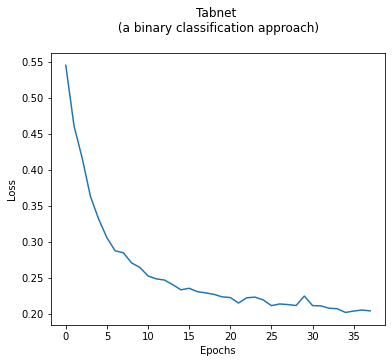

In [19]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(auc_clf.history['loss'])
plt.title('Tabnet \n (a binary classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend()
plt.show()

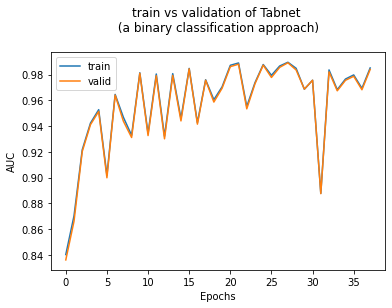

In [20]:
# plot auc
plt.plot(auc_clf.history['train_auc'], label="train")
plt.plot(auc_clf.history['valid_auc'], label="valid")

plt.title('train vs validation of Tabnet \n (a binary classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()

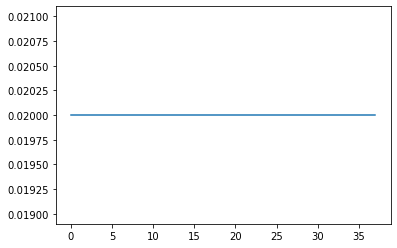

In [21]:
# plot learning rates
plt.plot(auc_clf.history['lr'])

In [22]:
preds = auc_clf.predict_proba(X_test)
test_auc = roc_auc_score(y_score=preds[:,1], y_true=y_test)


preds_valid = auc_clf.predict_proba(X_valid)
valid_auc = roc_auc_score(y_score=preds_valid[:,1], y_true=y_valid)

print(f"Best Valid Score : {round(auc_clf.best_cost, 4)}")
print(f"     Valid Score : {round(valid_auc, 4)}")
print(f"Final test score : {round(test_auc, 4)}")

Best Valid Score : 0.9892
     Valid Score : 0.9892
Final test score : 0.9882


In [23]:
# check that best weights are used
# assert np.isclose(valid_auc, np.max(clf.history['valid_logloss']), atol=1e-6)

In [24]:
auc_clf.predict(X_test)

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

##### _Evaluate_

In [25]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = auc_clf.predict(X_valid)
y_pred_train = auc_clf.predict(X_train)
y_pred_test = auc_clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.9448874090948918
Train Accuracy: 0.947316538882804
Test Accuracy: 0.9449766355140187


Evaluate using test set :

In [26]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = auc_clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9449766355140187


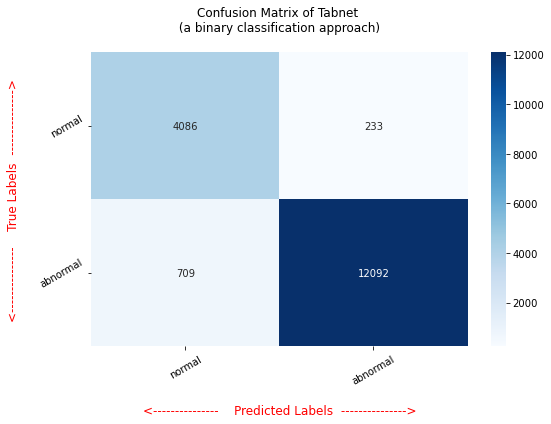

In [27]:
from sklearn.metrics import confusion_matrix, classification_report


# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt

labeled_classes = ['normal', 'abnormal']
classes = [0+0.5, 1+0.5]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet \n (a binary classification approach) \n ')
plt.tight_layout()
plt.show()

In [34]:
# Display a classification report
print("                  TabNet Classification Report")
print("                (a binary classification approach) \n")
print(classification_report(y_test, y_pred_test))

                  TabNet Classification Report
                (a binary classification approach) 

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      4319
           1       0.98      0.94      0.96     12801

    accuracy                           0.94     17120
   macro avg       0.92      0.95      0.93     17120
weighted avg       0.95      0.94      0.95     17120



##### _Global explainability : feat importance summing to 1_

In [35]:
scorez = auc_clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.230175,5,1
1,nb_nodes,0.144518,19,2
2,P.1203,0.085747,13,3
3,Act_Rate,0.081576,6,4
4,Byte_Size,0.078488,7,5
5,Yu,0.077434,17,6
6,mos,0.062606,20,7
7,Width,0.057962,9,8
8,Clae,0.041483,14,9
9,Buff_Level,0.039981,8,10


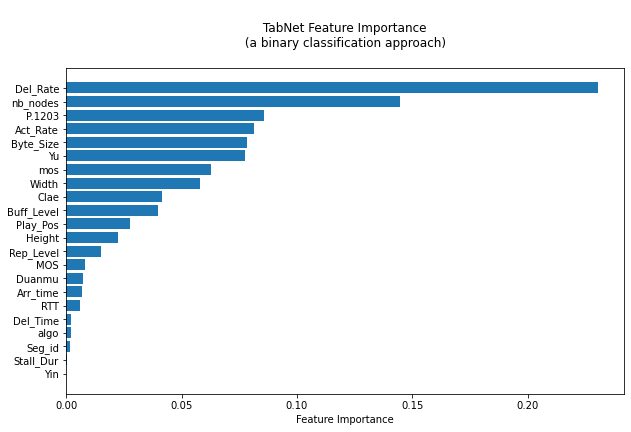

In [41]:
feature_importance = auc_clf.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance \n (a binary classification approach) \n")
plt.show()

#### _Local explainability and masks_

In [42]:
explain_matrix, masks = auc_clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2])


(50, 22)

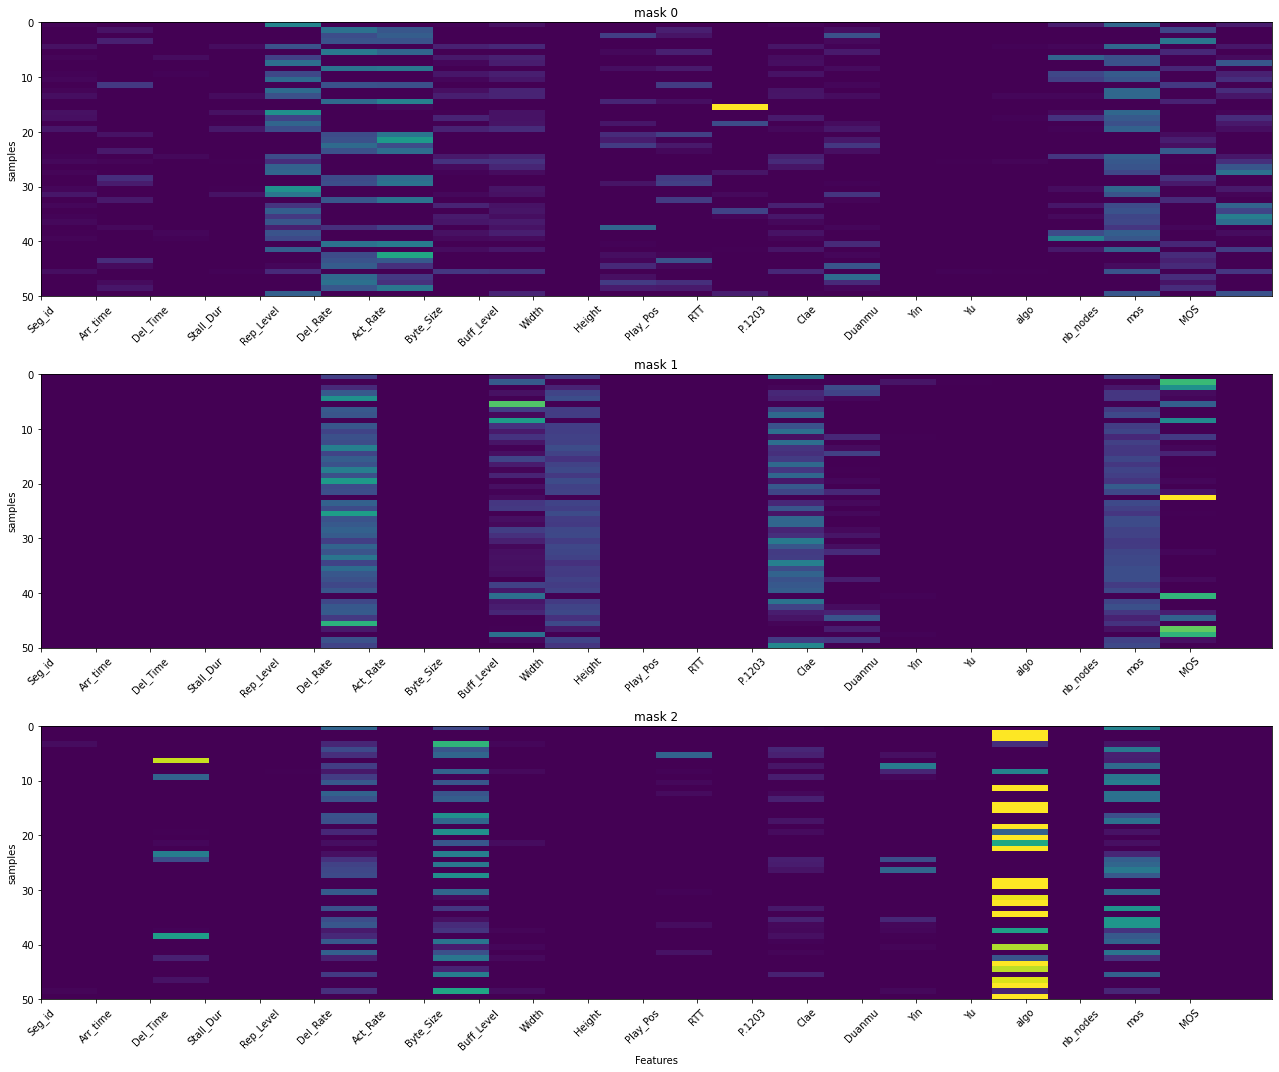

In [43]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 450, 50, 0], aspect=2)
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

### _2. Using logloss_

In [44]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 # "grouped_features" : grouped_features,
                 "device_name" : "auto"                 
                }

loss_clf = TabNetClassifier(**tabnet_params)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [45]:
# This illustrates the warm_start=False behaviour
save_history = []
start_time = time.time()

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    loss_clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['logloss'],
        max_epochs=max_epochs , # patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True
    )
    save_history.append(loss_clf.history["valid_logloss"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

print(f"Training completed in {(time.time()-start_time)//60:.2f} mnt.")

epoch 0  | loss: 0.54482 | train_logloss: 0.55953 | valid_logloss: 0.56168 |  0:00:04s
epoch 1  | loss: 0.46099 | train_logloss: 0.49025 | valid_logloss: 0.49427 |  0:00:10s
epoch 2  | loss: 0.41597 | train_logloss: 0.41848 | valid_logloss: 0.42255 |  0:00:15s
epoch 3  | loss: 0.36301 | train_logloss: 0.40237 | valid_logloss: 0.4031  |  0:00:21s
epoch 4  | loss: 0.33167 | train_logloss: 0.27939 | valid_logloss: 0.28299 |  0:00:27s
epoch 5  | loss: 0.30592 | train_logloss: 0.34331 | valid_logloss: 0.34691 |  0:00:33s
epoch 6  | loss: 0.28775 | train_logloss: 0.27657 | valid_logloss: 0.2786  |  0:00:39s
epoch 7  | loss: 0.28516 | train_logloss: 0.2864  | valid_logloss: 0.29226 |  0:00:45s
epoch 8  | loss: 0.27101 | train_logloss: 0.28087 | valid_logloss: 0.2852  |  0:00:51s
epoch 9  | loss: 0.26485 | train_logloss: 0.19719 | valid_logloss: 0.19938 |  0:00:57s
epoch 10 | loss: 0.25297 | train_logloss: 0.34573 | valid_logloss: 0.34998 |  0:01:03s
epoch 11 | loss: 0.24895 | train_logloss: 0

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.54482 | train_logloss: 0.55953 | valid_logloss: 0.56168 |  0:00:05s
epoch 1  | loss: 0.46099 | train_logloss: 0.49025 | valid_logloss: 0.49427 |  0:00:12s
epoch 2  | loss: 0.41597 | train_logloss: 0.41848 | valid_logloss: 0.42255 |  0:00:18s
epoch 3  | loss: 0.36301 | train_logloss: 0.40237 | valid_logloss: 0.4031  |  0:00:23s
epoch 4  | loss: 0.33167 | train_logloss: 0.27939 | valid_logloss: 0.28299 |  0:00:29s
epoch 5  | loss: 0.30592 | train_logloss: 0.34331 | valid_logloss: 0.34691 |  0:00:35s
epoch 6  | loss: 0.28775 | train_logloss: 0.27657 | valid_logloss: 0.2786  |  0:00:41s
epoch 7  | loss: 0.28516 | train_logloss: 0.2864  | valid_logloss: 0.29226 |  0:00:47s
epoch 8  | loss: 0.27101 | train_logloss: 0.28087 | valid_logloss: 0.2852  |  0:00:52s
epoch 9  | loss: 0.26485 | train_logloss: 0.19719 | valid_logloss: 0.19938 |  0:00:58s
epoch 10 | loss: 0.25297 | train_logloss: 0.34573 | valid_logloss: 0.34998 |  0:01:04s
epoch 11 | loss: 0.24895 | train_logloss: 0

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 5.00 mnt.


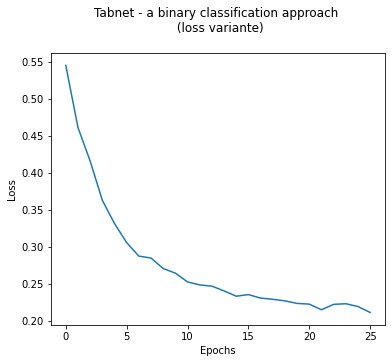

In [46]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(loss_clf.history['loss'])
plt.title('Tabnet - a binary classification approach \n (loss variante)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend()
plt.show()

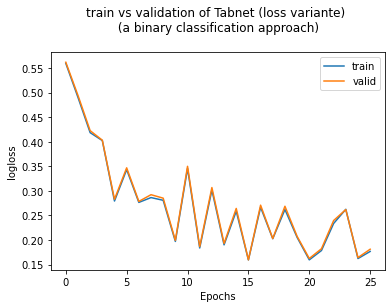

In [47]:
# plot logloss
plt.plot(loss_clf.history['train_logloss'], label="train")
plt.plot(loss_clf.history['valid_logloss'], label="valid")
plt.title('train vs validation of Tabnet (loss variante) \n (a binary classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('logloss')
plt.legend()

In [48]:
preds = loss_clf.predict_proba(X_test)
test_auc = roc_auc_score(y_score=preds[:,1], y_true=y_test)


preds_valid = loss_clf.predict_proba(X_valid)
valid_auc = roc_auc_score(y_score=preds_valid[:,1], y_true=y_valid)

print(f"Best Valid Score : {round(loss_clf.best_cost, 4)}")
print(f"     Valid Score : {round(valid_auc, 4)}")
print(f"Final test score : {round(test_auc, 4)}")

Best Valid Score : 0.1598
     Valid Score : 0.9845
Final test score : 0.9846


In [49]:
# check that best weights are used
# assert np.isclose(valid_auc, np.max(clf.history['valid_logloss']), atol=1e-6)

In [50]:
loss_clf.predict(X_test)

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

##### _Evaluate_

In [51]:
from sklearn.metrics import silhouette_score, accuracy_score, mean_squared_error, r2_score

# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = loss_clf.predict(X_valid)
y_pred_train = loss_clf.predict(X_train)
y_pred_test = loss_clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.938973100849908
Train Accuracy: 0.9391018619934283
Test Accuracy: 0.9394275700934579


Evaluate using test set :

In [52]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = loss_clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9394275700934579


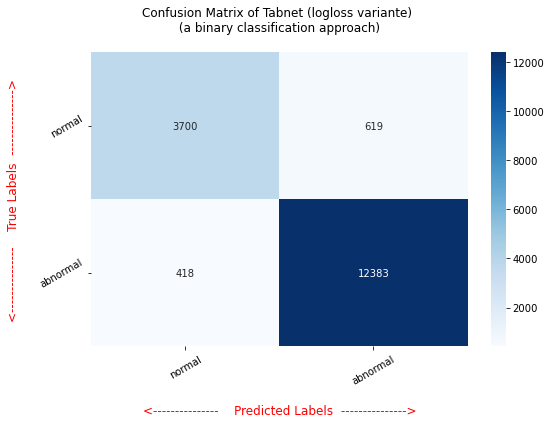

In [53]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt

labeled_classes = ['normal', 'abnormal']
classes = [0+0.5, 1+0.5]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet (logloss variante) \n (a binary classification approach) \n ')
plt.tight_layout()
plt.show()

In [54]:
# Display a classification report
print("            TabNet Classification Report (logloss variante)")
print("                (a binary classification approach) \n")
print(classification_report(y_test, y_pred_test))

            TabNet Classification Report (logloss variante)
                (a binary classification approach) 

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      4319
           1       0.95      0.97      0.96     12801

    accuracy                           0.94     17120
   macro avg       0.93      0.91      0.92     17120
weighted avg       0.94      0.94      0.94     17120



#### _Global explainability : feat importance summing to 1_

In [55]:
scorez = loss_clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.262662,5,1
1,Act_Rate,0.101077,6,2
2,nb_nodes,0.099728,19,3
3,Width,0.072098,9,4
4,Buff_Level,0.068987,8,5
5,P.1203,0.068951,13,6
6,mos,0.063765,20,7
7,Byte_Size,0.050010,7,8
8,Clae,0.045395,14,9
9,Height,0.044519,10,10


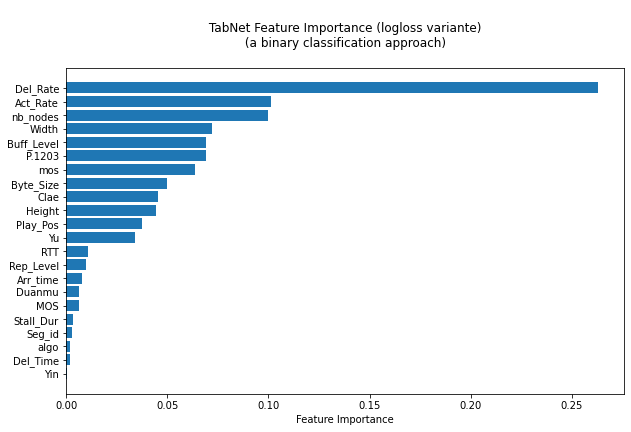

In [56]:
feature_importance = loss_clf.feature_importances_

# Map feature names to importance scores
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance (logloss variante) \n (a binary classification approach) \n")
plt.show()

#### _Local explainability and masks_

In [57]:
explain_matrix, masks = loss_clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2])


(50, 22)

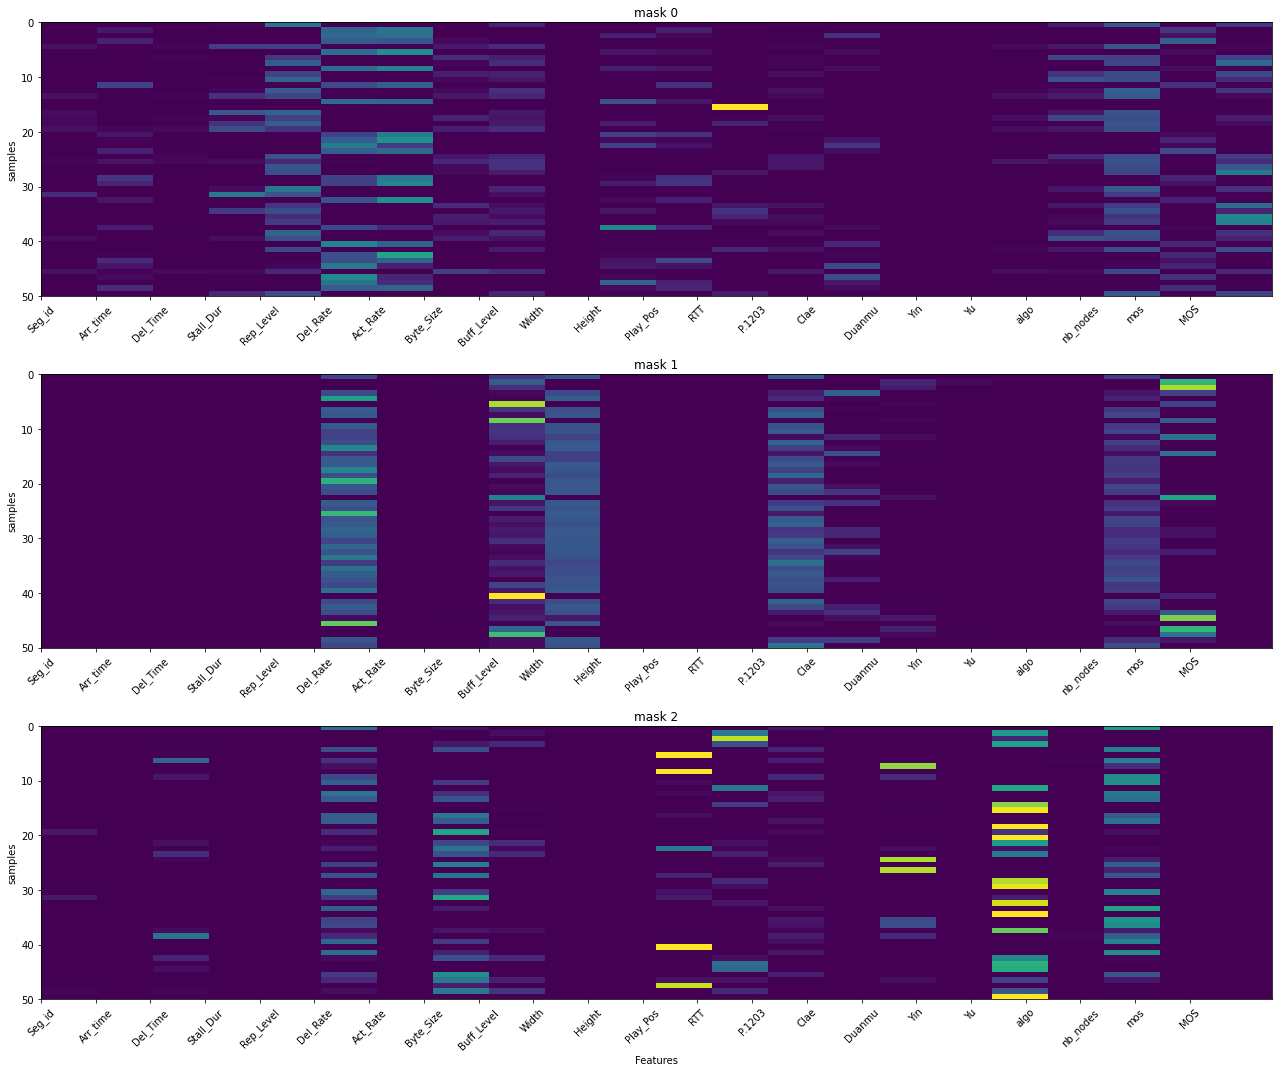

In [58]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 450, 50, 0], aspect=2)
    # axs[i].set(xticks=np.linspace(0, 23), xticklabels=np.linspace(0, 23), yticks=[0, 50], yticklabels=[0, 1]);    
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

_**c. Discussion**_

As we saw in the results, using either AUC or logloss does not has a considerable impact on the performance of our TabNet model.

Nevertheless, considering the little enhancement given by "AUC", we pick it as a representative of TabNet in binary anomaly detection approach.